
# ZZU Toy Dataset Generators

This notebook provides a consistent, well-documented set of toy and synthetic dataset generators for comparing transformation-based linearization, direct nonlinear regression, and hybrid methods.

The generators focus on the following functions:

1. Exponential growth with **multiplicative lognormal noise**,
2. Exponential growth with **additive Gaussian noise**,
3. A saturating nonlinear curve: **Michaelis-Menten** and **logistic growth** alternatives,
4. A **multivariable nonlinear dataset** combining exponential, power-law, and reciprocal effects.

Each generator returns a `DatasetBundle` containing:

- `X`: predictor dataframe
- `y`: observed noisy response
- `y_true`: noiseless signal from the known data-generating process
- `params`: all generation parameters needed for reproducibility and reporting
- `description`: a short explanation of what the dataset is designed to test



## 1. Imports and global settings


In [2]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Callable, Dict, Iterable, Mapping, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 20)
DEFAULT_OUTPUT_DIR = Path("generated_datasets")



## 2. Shared data container and utility functions

```python
bundle = make_some_dataset(n=200, seed=123, ...)
bundle.X        # predictors
bundle.y        # noisy observed response
bundle.y_true   # noiseless signal
bundle.to_frame()
```


In [3]:
@dataclass(frozen=True)
class DatasetBundle:
    """Container returned by every dataset generator.

    Attributes
    ----------
    name:
        Short machine-friendly dataset name.
    X:
        Predictor matrix as a pandas DataFrame. Column names are meaningful.
    y:
        Observed noisy response as a pandas Series named ``"y"``.
    y_true:
        Noiseless response generated from the known underlying function.
    params:
        Dictionary containing the parameters used to generate the dataset.
    description:
        Human-readable explanation of the dataset's purpose.
    """

    name: str
    X: pd.DataFrame
    y: pd.Series
    y_true: pd.Series
    params: Dict[str, Any] = field(default_factory=dict)
    description: str = ""

    def to_frame(self, include_true: bool = True) -> pd.DataFrame:
        """Return predictors and response as a single DataFrame.

        Parameters
        ----------
        include_true:
            If True, include the noiseless signal column ``y_true``.
        """
        out = self.X.copy()
        out["y"] = self.y.values
        if include_true:
            out["y_true"] = self.y_true.values
        return out

    def summary(self) -> pd.Series:
        """Return a compact summary useful for sanity checks."""
        return pd.Series(
            {
                "name": self.name,
                "n": len(self.y),
                "p": self.X.shape[1],
                "y_mean": float(self.y.mean()),
                "y_std": float(self.y.std(ddof=1)),
                "y_min": float(self.y.min()),
                "y_max": float(self.y.max()),
                "noise_type": self.params.get("noise_type", "unknown"),
                "seed": self.params.get("seed", None),
            }
        )


def make_rng(seed: Optional[int] = None) -> np.random.Generator:
    """Create a NumPy random number generator.

    Using ``np.random.default_rng`` keeps the generators reproducible without
    touching NumPy's global random state.
    """
    return np.random.default_rng(seed)


def evenly_spaced_x(n: int, x_min: float, x_max: float, name: str = "x") -> pd.DataFrame:
    """Create a one-column DataFrame with evenly spaced predictor values."""
    if n <= 1:
        raise ValueError("n must be greater than 1 for an evenly spaced dataset.")
    if not x_min < x_max:
        raise ValueError("x_min must be smaller than x_max.")
    return pd.DataFrame({name: np.linspace(x_min, x_max, n)})


def additive_gaussian_noise(
    y_true: np.ndarray,
    sigma: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """Add zero-mean Gaussian noise to a noiseless signal."""
    if sigma < 0:
        raise ValueError("sigma must be nonnegative.")
    return y_true + rng.normal(loc=0.0, scale=sigma, size=len(y_true))


def multiplicative_lognormal_noise(
    y_true: np.ndarray,
    log_sigma: float,
    rng: np.random.Generator,
    log_mean: float = 0.0,
) -> np.ndarray:
    """Apply multiplicative lognormal noise.

    The observed response is

    ``y = y_true * eta`` where ``log(eta) ~ Normal(log_mean, log_sigma^2)``.

    Notes
    -----
    - With ``log_mean=0``, the transformed model ``log(y)`` has zero-mean
      additive Gaussian noise around ``log(y_true)``.
    - With ``log_mean=-0.5 * log_sigma**2``, the multiplier has mean one,
      so ``E[y | x] = y_true``.
    """
    if log_sigma < 0:
        raise ValueError("log_sigma must be nonnegative.")
    if np.any(y_true <= 0):
        raise ValueError("y_true must be positive for multiplicative lognormal noise.")
    eta = rng.lognormal(mean=log_mean, sigma=log_sigma, size=len(y_true))
    return y_true * eta


def train_test_split_bundle(
    bundle: DatasetBundle,
    test_size: float = 0.25,
    seed: Optional[int] = 123,
) -> Tuple[DatasetBundle, DatasetBundle]:
    """Split a DatasetBundle into train and test bundles.

    This avoids a dependency on scikit-learn and keeps the notebook self-contained.
    """
    if not 0 < test_size < 1:
        raise ValueError("test_size must be between 0 and 1.")

    rng = make_rng(seed)
    n = len(bundle.y)
    indices = rng.permutation(n)
    n_test = int(round(test_size * n))
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]

    def subset(idx: np.ndarray, suffix: str) -> DatasetBundle:
        X = bundle.X.iloc[idx].reset_index(drop=True)
        y = bundle.y.iloc[idx].reset_index(drop=True)
        y_true = bundle.y_true.iloc[idx].reset_index(drop=True)
        params = dict(bundle.params)
        params["split_seed"] = seed
        params["test_size"] = test_size
        return DatasetBundle(
            name=f"{bundle.name}_{suffix}",
            X=X,
            y=y,
            y_true=y_true,
            params=params,
            description=bundle.description,
        )

    return subset(train_idx, "train"), subset(test_idx, "test")



## 3. Dataset 1: Exponential Growth with Multiplicative Noise

This is a clean case for log-linearization. Since the noise is multiplicative, taking logs produces an additive-noise model:

$\log y = \log a + bx + \varepsilon, \qquad \varepsilon \sim N(0, \sigma^2).$

This dataset is expected to favor log-linearization, especially when model evaluation is done on the transformed scale or with an appropriate retransformation correction.


In [4]:
def make_exponential_multiplicative(
    n: int = 120,
    seed: Optional[int] = 101,
    x_min: float = 0.0,
    x_max: float = 5.0,
    a: float = 2.0,
    b: float = 0.7,
    log_sigma: float = 0.25,
    log_mean: float = 0.0,
) -> DatasetBundle:
    """Generate exponential growth with multiplicative lognormal noise.

    Data-generating process
    -----------------------
    ``y_true = a * exp(b * x)``

    ``y = y_true * eta`` where ``log(eta) ~ Normal(log_mean, log_sigma^2)``

    Why this dataset is useful
    --------------------------
    This is a favorable setting for log-linearization because ``log(y)`` is
    exactly linear in ``x`` up to additive Gaussian noise.
    """
    if a <= 0:
        raise ValueError("a must be positive.")

    rng = make_rng(seed)
    X = evenly_spaced_x(n, x_min, x_max)
    x = X["x"].to_numpy()
    y_true_values = a * np.exp(b * x)
    y_values = multiplicative_lognormal_noise(
        y_true=y_true_values,
        log_sigma=log_sigma,
        log_mean=log_mean,
        rng=rng,
    )

    return DatasetBundle(
        name="exponential_multiplicative",
        X=X,
        y=pd.Series(y_values, name="y"),
        y_true=pd.Series(y_true_values, name="y_true"),
        params={
            "seed": seed,
            "n": n,
            "x_min": x_min,
            "x_max": x_max,
            "a": a,
            "b": b,
            "log_sigma": log_sigma,
            "log_mean": log_mean,
            "noise_type": "multiplicative_lognormal",
            "formula": "y = a exp(bx) eta; log(eta) ~ N(log_mean, log_sigma^2)",
            "suggested_linearization": "log(y) ~ 1 + x",
        },
        description=(
            "Best-case example for logarithmic linearization because the "
            "multiplicative lognormal noise becomes additive Gaussian noise "
            "after taking logs."
        ),
    )



## 4. Dataset 2: Exponential Growth with Additive Noise

This looks similar to the previous dataset, but it is intentionally different. The noise is additive on the original scale:

$y = ae^{bx} + \varepsilon.$

Taking logs no longer gives a clean linear model, because

$\log(ae^{bx} + \varepsilon)$

is not simply a linear function plus Gaussian noise. This dataset is useful for demonstrating residual distortion and retransformation bias.


In [5]:
def make_exponential_additive(
    n: int = 120,
    seed: Optional[int] = 102,
    x_min: float = 0.0,
    x_max: float = 5.0,
    a: float = 2.0,
    b: float = 0.7,
    sigma: float = 5.0,
    min_y: float = 1e-6,
) -> DatasetBundle:
    """Generate exponential growth with additive Gaussian noise.

    Data-generating process
    -----------------------
    ``y_true = a * exp(b * x)``

    ``y = y_true + epsilon`` where ``epsilon ~ Normal(0, sigma^2)``

    Why this dataset is useful
    --------------------------
    Naive log-linearization can be misleading here because the additive noise
    does not stay additive after taking logs. If noise is large, some observed
    responses can become nonpositive; such values are clipped to ``min_y`` so
    log-based methods can still be demonstrated, while the clipping is recorded
    in metadata.
    """
    if a <= 0:
        raise ValueError("a must be positive.")
    if min_y <= 0:
        raise ValueError("min_y must be positive.")

    rng = make_rng(seed)
    X = evenly_spaced_x(n, x_min, x_max)
    x = X["x"].to_numpy()
    y_true_values = a * np.exp(b * x)
    raw_y = additive_gaussian_noise(y_true_values, sigma=sigma, rng=rng)
    y_values = np.maximum(raw_y, min_y)
    n_clipped = int(np.sum(raw_y <= min_y))

    return DatasetBundle(
        name="exponential_additive",
        X=X,
        y=pd.Series(y_values, name="y"),
        y_true=pd.Series(y_true_values, name="y_true"),
        params={
            "seed": seed,
            "n": n,
            "x_min": x_min,
            "x_max": x_max,
            "a": a,
            "b": b,
            "sigma": sigma,
            "min_y": min_y,
            "n_clipped": n_clipped,
            "noise_type": "additive_gaussian",
            "formula": "y = a exp(bx) + epsilon; epsilon ~ N(0, sigma^2)",
            "suggested_linearization": "log(y) ~ 1 + x, but residual diagnostics should fail more often",
        },
        description=(
            "Failure-mode example for naive log-linearization: the model is "
            "exponential, but the noise is additive on the original scale."
        ),
    )



## 5. Dataset 3A: Michaelis-Menten Saturation Curve

This dataset represents a saturating nonlinear relationship:

$y = \frac{V_{\max}x}{K_m + x} + \varepsilon.$


In [6]:
def make_michaelis_menten(
    n: int = 120,
    seed: Optional[int] = 103,
    x_min: float = 0.1,
    x_max: float = 20.0,
    vmax: float = 10.0,
    km: float = 2.0,
    sigma: float = 0.30,
    min_y: float = 1e-6,
) -> DatasetBundle:
    """Generate a Michaelis--Menten saturation curve with additive noise.

    Data-generating process
    -----------------------
    ``y_true = vmax * x / (km + x)``

    ``y = y_true + epsilon`` where ``epsilon ~ Normal(0, sigma^2)``

    Why this dataset is useful
    --------------------------
    This curve is nonlinear but interpretable. Reciprocal-style linearizations
    can be tested against direct nonlinear optimization, but the transformed
    residuals often reveal distortion.
    """
    if vmax <= 0:
        raise ValueError("vmax must be positive.")
    if km <= 0:
        raise ValueError("km must be positive.")
    if min_y <= 0:
        raise ValueError("min_y must be positive.")

    rng = make_rng(seed)
    X = evenly_spaced_x(n, x_min, x_max)
    x = X["x"].to_numpy()
    y_true_values = vmax * x / (km + x)
    raw_y = additive_gaussian_noise(y_true_values, sigma=sigma, rng=rng)
    y_values = np.maximum(raw_y, min_y)
    n_clipped = int(np.sum(raw_y <= min_y))

    return DatasetBundle(
        name="michaelis_menten",
        X=X,
        y=pd.Series(y_values, name="y"),
        y_true=pd.Series(y_true_values, name="y_true"),
        params={
            "seed": seed,
            "n": n,
            "x_min": x_min,
            "x_max": x_max,
            "vmax": vmax,
            "km": km,
            "sigma": sigma,
            "min_y": min_y,
            "n_clipped": n_clipped,
            "noise_type": "additive_gaussian",
            "formula": "y = vmax * x / (km + x) + epsilon",
            "suggested_linearization": "1/y ~ 1/x or x/y ~ 1 + x, with caution",
        },
        description=(
            "Saturating nonlinear curve where direct nonlinear fitting is often "
            "more faithful than reciprocal linearization."
        ),
    )



## 6. Dataset 3B: Logistic Growth Curve

The logistic curve is another good choice for the third recommended dataset:

$y = \frac{L}{1 + e^{-k(x - x_0)}} + \varepsilon.$

This one is especially useful for studying sensitivity to initialization in gradient descent, Gauss-Newton, and BFGS.


In [7]:
def make_logistic_growth(
    n: int = 140,
    seed: Optional[int] = 104,
    x_min: float = 0.0,
    x_max: float = 10.0,
    L: float = 100.0,
    k: float = 1.2,
    x0: float = 5.0,
    sigma: float = 3.0,
) -> DatasetBundle:
    """Generate a logistic growth curve with additive Gaussian noise.

    Data-generating process
    -----------------------
    ``y_true = L / (1 + exp(-k * (x - x0)))``

    ``y = y_true + epsilon`` where ``epsilon ~ Normal(0, sigma^2)``

    Why this dataset is useful
    --------------------------
    Logistic curves are common in growth and saturation settings. They are
    useful for testing nonlinear optimizers because poor initial guesses for
    ``L``, ``k``, or ``x0`` can lead to unstable or slow convergence.
    """
    if L <= 0:
        raise ValueError("L must be positive.")
    if k == 0:
        raise ValueError("k must be nonzero.")

    rng = make_rng(seed)
    X = evenly_spaced_x(n, x_min, x_max)
    x = X["x"].to_numpy()
    y_true_values = L / (1.0 + np.exp(-k * (x - x0)))
    y_values = additive_gaussian_noise(y_true_values, sigma=sigma, rng=rng)

    return DatasetBundle(
        name="logistic_growth",
        X=X,
        y=pd.Series(y_values, name="y"),
        y_true=pd.Series(y_true_values, name="y_true"),
        params={
            "seed": seed,
            "n": n,
            "x_min": x_min,
            "x_max": x_max,
            "L": L,
            "k": k,
            "x0": x0,
            "sigma": sigma,
            "noise_type": "additive_gaussian",
            "formula": "y = L / (1 + exp(-k(x - x0))) + epsilon",
            "suggested_linearization": "not recommended as primary method; use nonlinear fitting",
        },
        description=(
            "Logistic S-curve for testing direct nonlinear regression and "
            "optimizer sensitivity to initialization."
        ),
    )



## 7. Dataset 4: Multivariable Nonlinear Dataset

This is the most important synthetic dataset for demonstrating a hybrid workflow because no single simple transformation fully linearizes the full data-generating process:

$y = 2e^{0.4x_1} + 3x_2^{1.5} + \frac{10}{1+x_3} + \varepsilon.$

It mixes exponential, power-law, and reciprocal components, allowing you to test robustness across repeated splits, noise levels, and initialization strategies.

In [8]:
def make_multivariable_nonlinear(
    n: int = 500,
    seed: Optional[int] = 105,
    x1_range: Tuple[float, float] = (0.0, 5.0),
    x2_range: Tuple[float, float] = (1.0, 10.0),
    x3_range: Tuple[float, float] = (0.0, 20.0),
    exp_coef: float = 2.0,
    exp_rate: float = 0.4,
    power_coef: float = 3.0,
    power: float = 1.5,
    reciprocal_coef: float = 10.0,
    sigma: float = 5.0,
) -> DatasetBundle:
    """Generate a multivariable nonlinear regression dataset.

    Data-generating process
    -----------------------
    ``x1 ~ Uniform(x1_range)``

    ``x2 ~ Uniform(x2_range)``

    ``x3 ~ Uniform(x3_range)``

    ``y_true = exp_coef * exp(exp_rate * x1) + power_coef * x2**power + reciprocal_coef / (1 + x3)``

    ``y = y_true + epsilon`` where ``epsilon ~ Normal(0, sigma^2)``

    Why this dataset is useful
    --------------------------
    This dataset is deliberately not solved by one global response
    transformation. It is designed for comparing transformation screening,
    residual diagnostics, nonlinear warm-starting, and repeated-split
    robustness.
    """
    for label, bounds in {"x1_range": x1_range, "x2_range": x2_range, "x3_range": x3_range}.items():
        if len(bounds) != 2 or not bounds[0] < bounds[1]:
            raise ValueError(f"{label} must be a tuple (low, high) with low < high.")
    if n <= 0:
        raise ValueError("n must be positive.")

    rng = make_rng(seed)
    x1 = rng.uniform(*x1_range, size=n)
    x2 = rng.uniform(*x2_range, size=n)
    x3 = rng.uniform(*x3_range, size=n)

    y_true_values = (
        exp_coef * np.exp(exp_rate * x1)
        + power_coef * np.power(x2, power)
        + reciprocal_coef / (1.0 + x3)
    )
    y_values = additive_gaussian_noise(y_true_values, sigma=sigma, rng=rng)

    X = pd.DataFrame({"x1": x1, "x2": x2, "x3": x3})
    return DatasetBundle(
        name="multivariable_nonlinear",
        X=X,
        y=pd.Series(y_values, name="y"),
        y_true=pd.Series(y_true_values, name="y_true"),
        params={
            "seed": seed,
            "n": n,
            "x1_range": x1_range,
            "x2_range": x2_range,
            "x3_range": x3_range,
            "exp_coef": exp_coef,
            "exp_rate": exp_rate,
            "power_coef": power_coef,
            "power": power,
            "reciprocal_coef": reciprocal_coef,
            "sigma": sigma,
            "noise_type": "additive_gaussian",
            "formula": "y = exp_coef*exp(exp_rate*x1) + power_coef*x2^power + reciprocal_coef/(1+x3) + epsilon",
            "suggested_linearization": "no single global linearization; test ZZU-style screening and nonlinear warm starts",
        },
        description=(
            "Synthetic multivariable benchmark combining exponential, power-law, "
            "and reciprocal effects; intended to stress-test hybrid workflows."
        ),
    )



## 8. Generation

Following code makes it easy to generate a consistent benchmark suite and loop over datasets during experiments.


In [9]:
DATASET_GENERATORS: Mapping[str, Callable[..., DatasetBundle]] = {
    "exponential_multiplicative": make_exponential_multiplicative,
    "exponential_additive": make_exponential_additive,
    "michaelis_menten": make_michaelis_menten,
    "logistic_growth": make_logistic_growth,
    "multivariable_nonlinear": make_multivariable_nonlinear,
}

def generate_default_suite() -> Dict[str, DatasetBundle]:
    """Generate all default benchmark datasets.

    Returns
    -------
    dict
        Mapping from dataset name to DatasetBundle.
    """
    return {name: generator() for name, generator in DATASET_GENERATORS.items()}


def summarize_suite(suite: Mapping[str, DatasetBundle]) -> pd.DataFrame:
    """Summarize a dictionary of DatasetBundle objects."""
    return pd.DataFrame([bundle.summary() for bundle in suite.values()]).set_index("name")


def export_suite_to_csv(
    suite: Mapping[str, DatasetBundle],
    output_dir: Path | str = DEFAULT_OUTPUT_DIR,
    include_true: bool = True,
) -> Dict[str, Path]:
    """Export each generated dataset to a CSV file.

    Parameters
    ----------
    suite:
        Mapping from names to DatasetBundle objects.
    output_dir:
        Destination directory.
    include_true:
        If True, include ``y_true`` in each exported CSV.

    Returns
    -------
    dict
        Mapping from dataset name to written CSV path.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    written = {}
    for name, bundle in suite.items():
        path = output_dir / f"{name}.csv"
        bundle.to_frame(include_true=include_true).to_csv(path, index=False)
        written[name] = path
    return written


In [10]:
suite = generate_default_suite()
summary = summarize_suite(suite)
summary

,n,p,y_mean,y_std,y_min,y_max,noise_type,seed
name,,,,,,,,
exponential_multiplicative,120,1,18.5223,18.4463,1.2385e+00,85.2818,multiplicative_lognormal,101
exponential_additive,120,1,18.5526,17.5177,1.0000e-06,68.3474,additive_gaussian,102
michaelis_menten,120,1,7.6159,1.8758,7.9472e-01,9.5393,additive_gaussian,103
logistic_growth,140,1,50.4224,40.9113,-2.0268e+00,105.5840,additive_gaussian,104
multivariable_nonlinear,500,3,47.7625,28.5636,-1.0092e+00,115.7288,additive_gaussian,105


In [11]:
# Inspect
suite["exponential_multiplicative"].to_frame().head()


,x,y,y_true
0,0.0000,1.6415,2.0000
1,0.0420,1.2385,2.0597
2,0.0840,2.4665,2.1212
3,0.1261,2.6312,2.1845
4,0.1681,2.0821,2.2497


## 10. Plotting Helpers

The following functions provide quick sanity checks. They are not modeling functions; they only visualize the generated data and the known noiseless signal.


In [12]:
def plot_one_dimensional_dataset(
    bundle: DatasetBundle,
    ax: Optional[plt.Axes] = None,
    title: Optional[str] = None,
) -> plt.Axes:
    """Plot observed and noiseless values for a one-predictor dataset."""
    if bundle.X.shape[1] != 1:
        raise ValueError("plot_one_dimensional_dataset expects exactly one predictor.")

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    x_name = bundle.X.columns[0]
    order = np.argsort(bundle.X[x_name].to_numpy())
    x = bundle.X[x_name].to_numpy()[order]
    y = bundle.y.to_numpy()[order]
    y_true = bundle.y_true.to_numpy()[order]

    ax.scatter(x, y, s=22, alpha=0.75, label="observed y")
    ax.plot(x, y_true, linewidth=2.5, label="true signal")
    ax.set_xlabel(x_name)
    ax.set_ylabel("y")
    ax.set_title(title or bundle.name)
    ax.legend()
    return ax


def plot_multivariable_marginals(
    bundle: DatasetBundle,
    figsize: Tuple[float, float] = (14, 4),
) -> plt.Figure:
    """Plot y against each predictor for a multivariable dataset."""
    p = bundle.X.shape[1]
    fig, axes = plt.subplots(1, p, figsize=figsize, constrained_layout=True)
    if p == 1:
        axes = [axes]

    for ax, col in zip(axes, bundle.X.columns):
        ax.scatter(bundle.X[col], bundle.y, s=18, alpha=0.60, label="observed y")
        ax.scatter(bundle.X[col], bundle.y_true, s=10, alpha=0.35, label="true signal")
        ax.set_xlabel(col)
        ax.set_ylabel("y")
        ax.set_title(f"{bundle.name}: y vs {col}")
    axes[0].legend()
    return fig


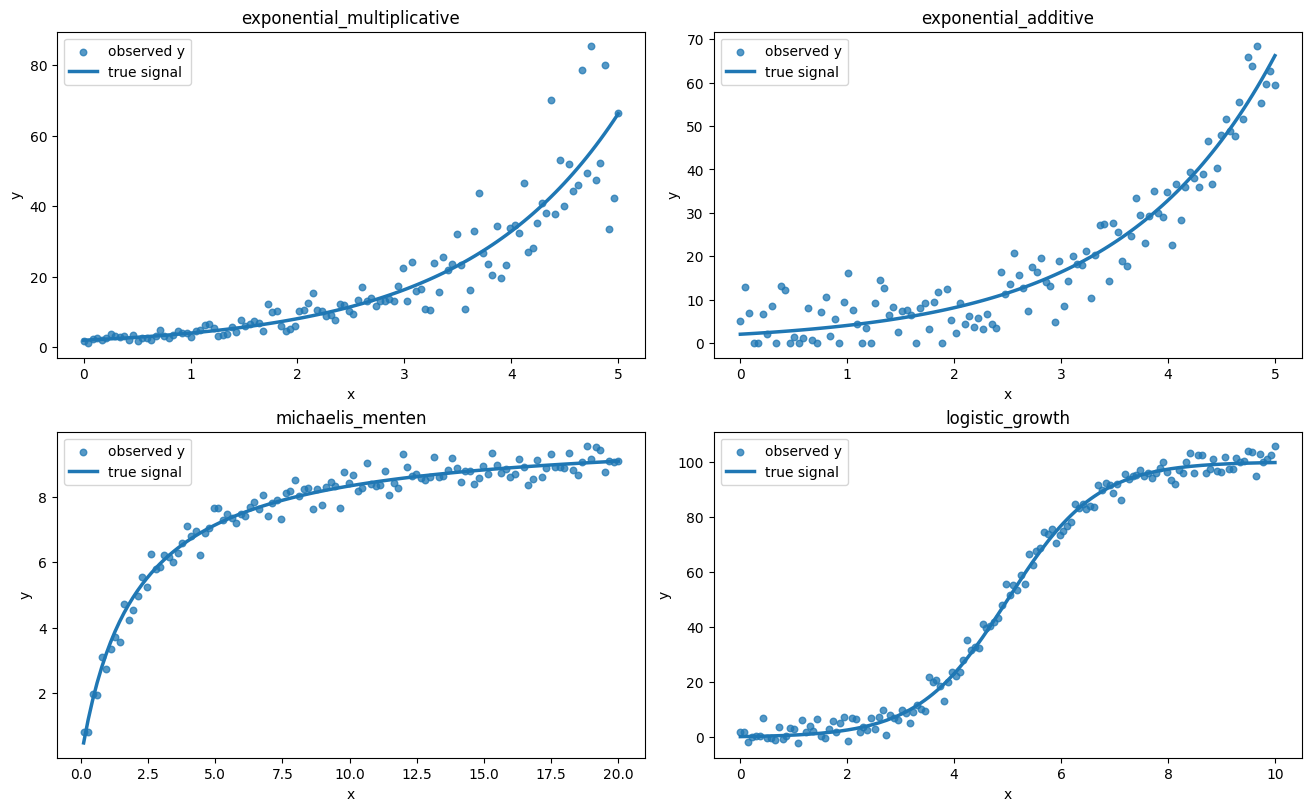

In [13]:
# Visualize 1D datasets.

one_d_names = [
    "exponential_multiplicative",
    "exponential_additive",
    "michaelis_menten",
    "logistic_growth",
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for ax, name in zip(axes.ravel(), one_d_names):
    plot_one_dimensional_dataset(suite[name], ax=ax)
plt.show()


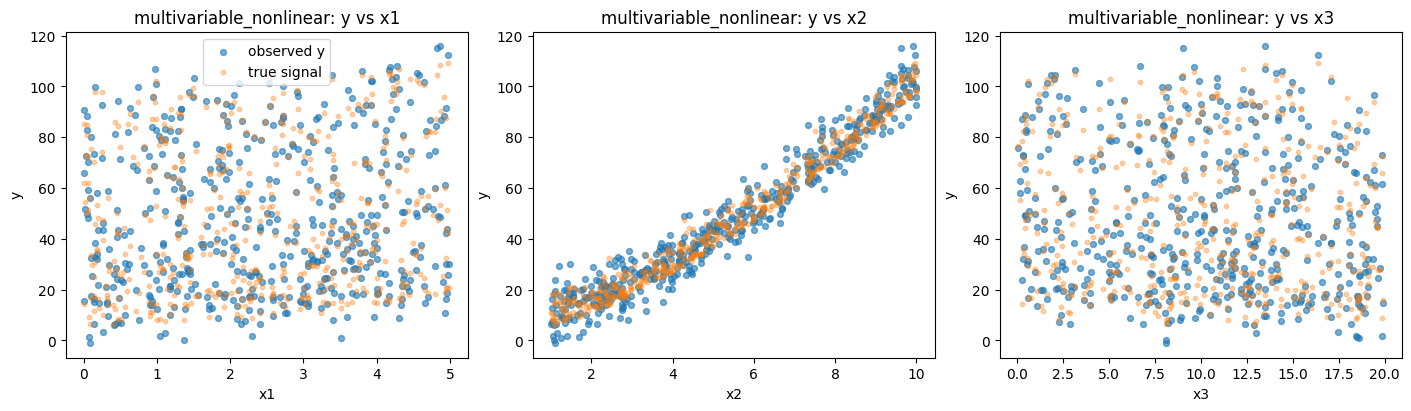

In [14]:
# Visualize multi-dim dataset.
plot_multivariable_marginals(suite["multivariable_nonlinear"])
plt.show()



## 11. Split datasets into train and test subsets.

This helper keeps splits reproducible and preserves the same `DatasetBundle` interface.


In [16]:
train_bundle, test_bundle = train_test_split_bundle(
    suite["multivariable_nonlinear"],
    test_size=0.2,
    seed=2026,
)

pd.DataFrame([train_bundle.summary(), test_bundle.summary()]).set_index("name")


,n,p,y_mean,y_std,y_min,y_max,noise_type,seed
name,,,,,,,,
multivariable_nonlinear_train,400,3,47.2534,27.9693,1.1525,115.0716,additive_gaussian,105
multivariable_nonlinear_test,100,3,49.7989,30.8916,-1.0092,115.7288,additive_gaussian,105



## 12. Noise-level stress tests

For robustness experiments, generate the same functional form across several noise levels. This is especially useful for RMSE/MAE/R² comparisons across repeated splits.


In [18]:
def generate_noise_grid(
    generator: Callable[..., DatasetBundle],
    noise_param: str,
    noise_values: Iterable[float],
    base_seed: int = 1000,
    **fixed_kwargs: Any,
) -> Dict[str, DatasetBundle]:
    """Generate multiple versions of a dataset across noise levels.

    Parameters
    ----------
    generator:
        A dataset generator function from the registry.
    noise_param:
        Name of the generator argument controlling noise, such as ``"sigma"``
        or ``"log_sigma"``.
    noise_values:
        Iterable of noise levels to test.
    base_seed:
        First seed used; each later noise level increments this seed by one.
    fixed_kwargs:
        Other generator arguments held constant.
    """
    out = {}
    for i, value in enumerate(noise_values):
        kwargs = dict(fixed_kwargs)
        kwargs[noise_param] = value
        kwargs["seed"] = base_seed + i
        bundle = generator(**kwargs)
        key = f"{bundle.name}_{noise_param}_{value:g}"
        out[key] = bundle
    return out

noise_grid = generate_noise_grid(
    make_exponential_additive,
    noise_param="sigma",
    noise_values=[1.0, 3.0, 5.0, 8.0],
    n=120,
)

summarize_suite(noise_grid)


,n,p,y_mean,y_std,y_min,y_max,noise_type,seed
name,,,,,,,,
exponential_additive,120,1,18.5034,17.1536,1.0591e+00,64.9051,additive_gaussian,1000
exponential_additive,120,1,18.8829,17.4682,1.0000e-06,67.7163,additive_gaussian,1001
exponential_additive,120,1,18.2234,17.5525,1.0000e-06,64.2953,additive_gaussian,1002
exponential_additive,120,1,18.1614,17.2840,1.0000e-06,73.9715,additive_gaussian,1003



## 13. CSV Export

In [17]:
written_files = export_suite_to_csv(suite, output_dir=DEFAULT_OUTPUT_DIR)
written_files


{'exponential_multiplicative': PosixPath('generated_datasets/exponential_multiplicative.csv'),
 'exponential_additive': PosixPath('generated_datasets/exponential_additive.csv'),
 'michaelis_menten': PosixPath('generated_datasets/michaelis_menten.csv'),
 'logistic_growth': PosixPath('generated_datasets/logistic_growth.csv'),
 'multivariable_nonlinear': PosixPath('generated_datasets/multivariable_nonlinear.csv')}